In [1]:
!pip install pandas networkx matplotlib

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------------- ------------------- 1.0/2.1 MB 16.7 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 19.2 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


🔥 Memulai Analisis Graf Pak Menteri! 🔥

✅ Graf terbentuk dengan 7 Node dan 8 Edge.

👑 TOP 3 TOKOH PALING BERPENGARUH (CENTRALITY):
- Tribhuwana Wijayatunggadewi (Skor: 0.67)
- Raden Wijaya (Skor: 0.50)
- Gayatri (Skor: 0.50)

👯‍♂️ DETEKSI KOMUNITAS (SIRKEL WANGSA):
Sirkel 1: ['Kertanegara', 'Gayatri', 'Lembu Tal', 'Raden Wijaya']
Sirkel 2: ['Tribhuwana Wijayatunggadewi', 'Hayam Wuruk', 'Kertawardhana']

🪞 KEMIRIPAN TOKOH (JACCARD SIMILARITY):
- Lembu Tal dan Gayatri memiliki tingkat kemiripan sirkel: 0.33
- Raden Wijaya dan Kertanegara memiliki tingkat kemiripan sirkel: 0.33
- Lembu Tal dan Tribhuwana Wijayatunggadewi memiliki tingkat kemiripan sirkel: 0.25


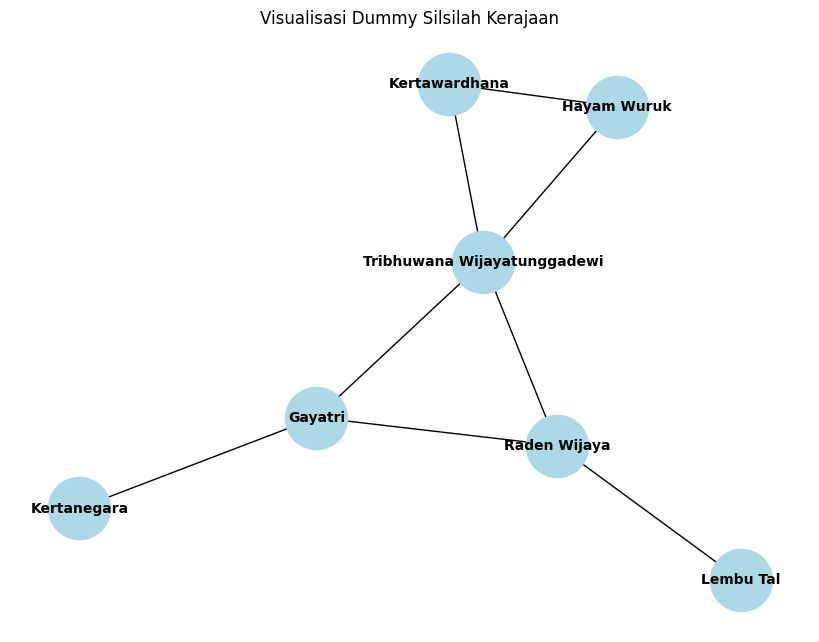

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community

print("🔥 Memulai Analisis Graf Pak Menteri! 🔥\n")

# 1. Baca Data Dummy
df = pd.read_csv("dataset_dummy.csv")

# 2. Inisialisasi Graf Kosong (Bisa bolak-balik / Undirected untuk relasi keluarga)
G = nx.Graph()

# 3. Masukin Node dan Edge ke dalam Graf
for index, row in df.iterrows():
    tokoh = str(row['Nama_Tokoh'])
    ayah = str(row['Ayah'])
    ibu = str(row['Ibu'])
    pasangan = str(row['Pasangan'])
    
    # Tambah properti kerajaan dan sejarah ke node utama
    G.add_node(tokoh, kerajaan=row['Kerajaan'], sejarah=row['Abstrak_Sejarah'])
    
    # Jahit relasinya! (Pastikan datanya ngga kosong / 'nan')
    if ayah != 'nan' and ayah != '':
        G.add_edge(ayah, tokoh, relasi="AYAH_DARI")
    if ibu != 'nan' and ibu != '':
        G.add_edge(ibu, tokoh, relasi="IBU_DARI")
    if pasangan != 'nan' and pasangan != '':
        G.add_edge(tokoh, pasangan, relasi="MENIKAH_DENGAN")

print(f"✅ Graf terbentuk dengan {G.number_of_nodes()} Node dan {G.number_of_edges()} Edge.\n")

# 4. ALGORITMA 1: DEGREE CENTRALITY (Siapa paling sibuk/banyak relasi?)
print("👑 TOP 3 TOKOH PALING BERPENGARUH (CENTRALITY):")
centrality = nx.degree_centrality(G)
# Urutin dari yang paling gede
sorted_centrality = sorted(centrality.items(), key=lambda item: item[1], reverse=True)
for tokoh, skor in sorted_centrality[:3]:
    print(f"- {tokoh} (Skor: {skor:.2f})")

# 5. ALGORITMA 2: COMMUNITY DETECTION (Sirkel Keluarga)
print("\n👯‍♂️ DETEKSI KOMUNITAS (SIRKEL WANGSA):")
komunitas = list(community.greedy_modularity_communities(G))
for i, sirkel in enumerate(komunitas):
    print(f"Sirkel {i+1}: {list(sirkel)}")
    
# 6. ALGORITMA 3: SIMILARITY (Jaccard Coefficient)
# Mengukur seberapa mirip dua tokoh berdasarkan kesamaan sirkel keluarganya (tetangga node)
print("\n🪞 KEMIRIPAN TOKOH (JACCARD SIMILARITY):")

# Hitung Jaccard untuk semua kemungkinan pasangan di dalam graf
preds = nx.jaccard_coefficient(G)
# Urutkan dari yang skornya paling tinggi (paling mirip)
sorted_preds = sorted(preds, key=lambda x: x[2], reverse=True)

# Tampilkan 3 pasangan yang paling mirip dan skornya di atas 0
for u, v, p in sorted_preds[:3]:
    if p > 0:
        print(f"- {u} dan {v} memiliki tingkat kemiripan sirkel: {p:.2f}")

# 6. Gambar Grafnya buat Laporan!
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42) # Biar posisinya ngga berubah-ubah pas di run
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, font_weight='bold')
plt.title("Visualisasi Dummy Silsilah Kerajaan")
plt.show()